# redMaPPer Input Validation for cosmoDC2

Loads and visualizes the five redMaPPer ingredients built by `make_redmapper_inits.py` and `make_redmapper_maps.py`:

1. **Spec-z training catalog**: `cdc2_rmpr/Funcs/redmapper_inputs/cosmodc2_specz.fits`
2. **Photometric galaxy catalog**:`cdc2_rmpr/Funcs/redmapper_inputs/cosmodc2_photoz.fits`
3. **Initial red-sequence template**: `cdc2_rmpr/Funcs/redmapper_inputs/cosmodc2_redsequence_init.fit`
4. **Survey geometry mask**: `cdc2_rmpr/Funcs/redmapper_inputs/cosmodc2_geometry_mask.hs`
5. **Depth mask**: `cdc2_rmpr/Funcs/redmapper_inputs/cosmodc2_depth_mask.hs`

I set up a `desc_rm` conda kernel, not sure if that's accessible by others. 

The two build scripts have already been run from the command line for myself, so by default this notebook just loads the existing output files. If you want to regenerate them from inside the notebook, run the optional cells in Section 1 that are currently commented out.

In [1]:
import os
import subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import healpy as hp
import healsparse as hsp
from redmapper import GalaxyCatalog

## 0. Setting up Config Stuff

In [2]:
# settings to match command line run
OUT_DIR = "../Funcs/redmapper_inputs/"
N_PER_BIN = 25 # spec-z centrals per dz=0.05 bin
ZMIN = 0.10
ZMAX = 0.90
MAG_CUT = 26.0 # z-band limiting magnitude
NSIDE_SPARSE = 4096 # set to this for speed at the moment, need to learn more about these maps/masks

# file paths
specz_path = os.path.join(OUT_DIR, "cosmodc2_specz.fits")
photo_path = os.path.join(OUT_DIR, "cosmodc2_photoz.fits")
rs_path = os.path.join(OUT_DIR, "cosmodc2_redsequence_init.fit")
geom_path = os.path.join(OUT_DIR, "cosmodc2_geometry_mask.hs")
depth_path = os.path.join(OUT_DIR, "cosmodc2_depth_mask.hs")

# check that the files are there
for label, p in [("spec-z", specz_path), ("photo", photo_path), ("red-seq", rs_path), ("geometry", geom_path),("depth", depth_path)]:
    print(f"{label:<10} {'OK' if os.path.isfile(p) else 'MISSING':<8} {p}") 

spec-z     OK       ../Funcs/redmapper_inputs/cosmodc2_specz.fits
photo      OK       ../Funcs/redmapper_inputs/cosmodc2_photoz.fits
red-seq    OK       ../Funcs/redmapper_inputs/cosmodc2_redsequence_init.fit
geometry   OK       ../Funcs/redmapper_inputs/cosmodc2_geometry_mask.hs
depth      OK       ../Funcs/redmapper_inputs/cosmodc2_depth_mask.hs


## 1. (Optional) Regenerate inputs from inside the notebook

Skip these two cells if you've already run the scripts from the command line.

In [3]:
# spec-z, photometric, red-sequence
'''
subprocess.run([sys.executable, "make_redmapper_inits.py", "--n-per-bin", 
                str(N_PER_BIN), "--zmin", str(ZMIN), "--zmax", str(ZMAX), "--mag-cut", str(MAG_CUT), "--out-dir", OUT_DIR])
'''

'\nsubprocess.run([sys.executable, "make_redmapper_inits.py", "--n-per-bin", \n                str(N_PER_BIN), "--zmin", str(ZMIN), "--zmax", str(ZMAX), "--mag-cut", str(MAG_CUT), "--out-dir", OUT_DIR])\n'

In [4]:
# geometry + depth masks
'''
subprocess.run([sys.executable, "make_redmapper_maps.py", "--nside-sparse", str(NSIDE_SPARSE), "--zmin", str(ZMIN), 
                "--zmax", str(ZMAX), "--mag-cut", str(MAG_CUT), "--out-dir", OUT_DIR])
'''

'\nsubprocess.run([sys.executable, "make_redmapper_maps.py", "--nside-sparse", str(NSIDE_SPARSE), "--zmin", str(ZMIN), \n                "--zmax", str(ZMAX), "--mag-cut", str(MAG_CUT), "--out-dir", OUT_DIR])\n'

## 2. Load outputs

In [5]:
plt.rcParams.update({"figure.dpi": 120, "font.size":  11, "axes.grid":  True, "grid.alpha": 0.3})

# spec-z (ra, dec, z, z_err)
specz = Table.read(specz_path)
print(f"Spec-z catalog: {len(specz):,} rows | columns: {specz.colnames}")

# photometric
'''
with fits.open(photo_path) as hdul:
    photo = hdul[1].data
    photo_hdr = hdul[1].header
'''
photo = GalaxyCatalog.from_galfile(os.path.join(OUT_DIR, "cosmodc2_photo_master_table.fit"))
#print(f"Photometric catalog: {len(photo):,} rows | columns: {photo.columns.names}")

print(f"Photometric catalog: {photo.size:,} galaxies")

# red-sequence template
rs = np.loadtxt(rs_path, comments="#", dtype=[("z","f4"), ("gr","f4"), ("ri","f4"), ("iz","f4"),( "zy","f4")])
print(f"Red-sequence template: {len(rs)} redshift bins")

# masks
geom_map  = hsp.HealSparseMap.read(geom_path)
depth_map = hsp.HealSparseMap.read(depth_path)
print(f"Geometry mask NSIDE: {geom_map.nside_sparse} | valid pixels: {len(geom_map.valid_pixels):,}")
print(f"Depth mask NSIDE: {depth_map.nside_sparse} | valid pixels: {len(depth_map.valid_pixels):,}")

Spec-z catalog: 640 rows | columns: ['ra', 'dec', 'z', 'z_err']
Photometric catalog: 71,717,949 galaxies
Red-sequence template: 40 redshift bins
Geometry mask NSIDE: 4096 | valid pixels: 2,152,136
Depth mask NSIDE: 4096 | valid pixels: 2,152,136


400 spec-z rows = 16 bins, 25 clusters each, all filled. 

Lots of galaxies

40 red-sequence bins (z=0.1-0.9 w dz=0.02)

Geometry and depth mask have same num of pixels so that's good

## 3. Spec-z training set
Purpose in redmapper: Provides the spectroscopically-confirmed cluster centrals that ground the red sequence model, calibrating the color-redshift relation

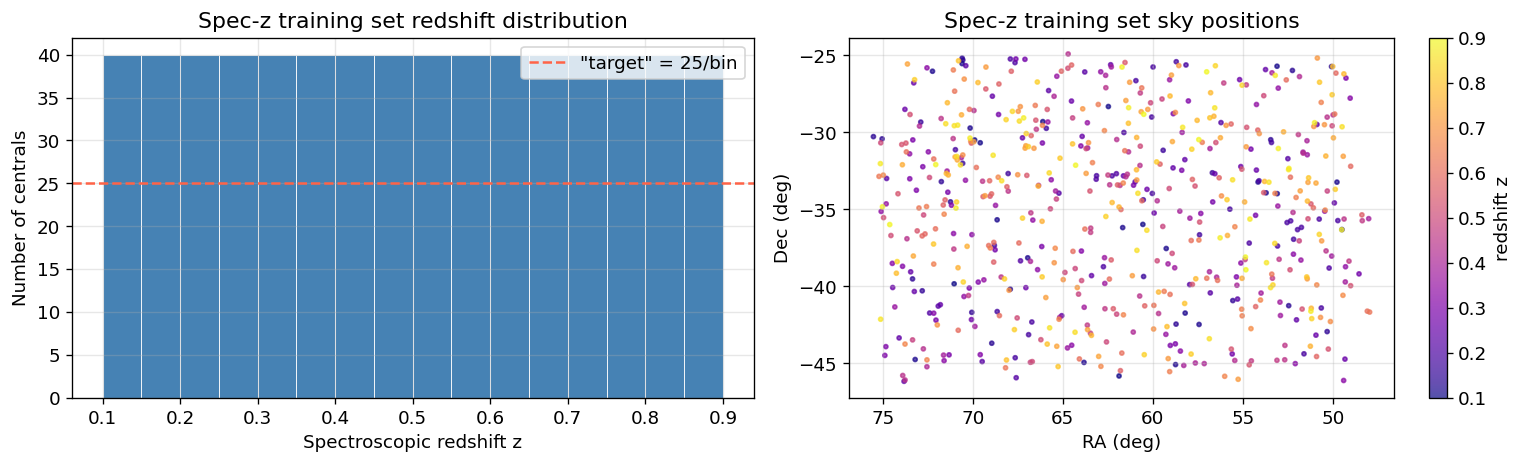

Total spec-z galaxies: 640


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bins = np.arange(ZMIN, ZMAX + 0.05, 0.05)
ax.hist(specz["z"], bins=bins, color="steelblue", edgecolor="white", lw=0.5)
ax.axhline(N_PER_BIN, color="tomato", ls="--", label=f"\"target\" = {N_PER_BIN}/bin")
ax.set_xlabel("Spectroscopic redshift z")
ax.set_ylabel("Number of centrals")
ax.set_title("Spec-z training set redshift distribution")
ax.legend()

ax = axes[1]
sc = ax.scatter(specz["ra"], specz["dec"], c=specz["z"], cmap="plasma", s=6, alpha=0.7, vmin=ZMIN, vmax=ZMAX)
plt.colorbar(sc, ax=ax, label="redshift z")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("Spec-z training set sky positions")
ax.invert_xaxis()

fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_specz.png"), dpi=150)
plt.show()
print(f"Total spec-z galaxies: {len(specz):,}")

Training set is uniformly sampled at the 25/bin across all 16 redshift bins

The centrals are spread evenly across the footprint (RA 50 to 75 deg, Dec -25 to −46 deg) with no spatial clustering that I notice

## 4. Photometric galaxy catalog
Purpose in redmapper: Supplies the full population of galaxies (with positions and ugrizy magnitudes) that redMaPPer actually searches to detect clusters as red-sequence overdensities

In [7]:
print(photo.ra.min(), photo.ra.max(), photo.dec.min(), photo.dec.max())

47.8099830188354 75.97287254648704 -46.60694933341967 -24.59513201507679


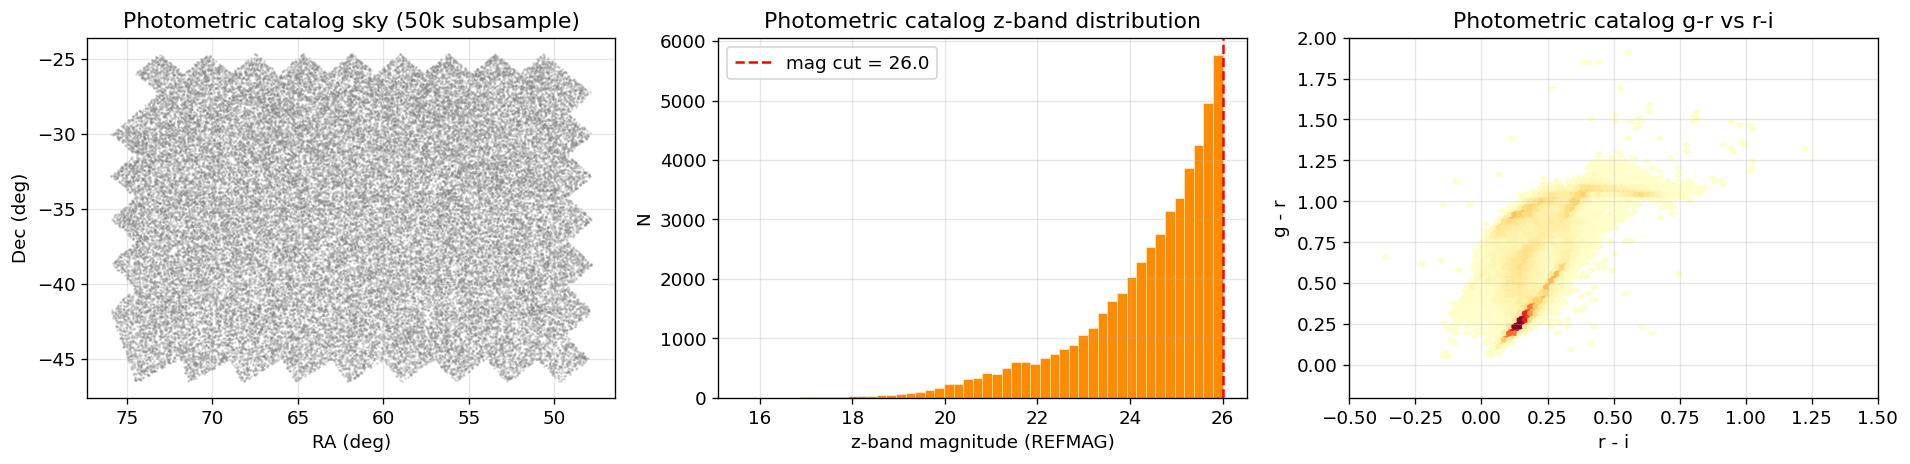

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# subsample for speed
#idx = np.random.choice(len(photo), size=min(50000, len(photo)), replace=False)
idx = np.random.choice(photo.size, size=min(50000, photo.size), replace=False)

ax = axes[0]
#ax.scatter(photo["RA"][idx], photo["DEC"][idx], s=0.3, alpha=0.3, color="gray")
ax.scatter(photo.ra[idx], photo.dec[idx], s=0.3, alpha=0.3, color="gray")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title(f"Photometric catalog sky (50k subsample)") #format later
ax.invert_xaxis()

ax = axes[1]
#ax.hist(photo["REFMAG"][idx], bins=50, color="darkorange", edgecolor="white", lw=0.3)
ax.hist(photo.refmag[idx], bins=50, color="darkorange", edgecolor="white", lw=0.3)
ax.axvline(MAG_CUT, color="red", ls="--", label=f"mag cut = {MAG_CUT}")
ax.set_xlabel("z-band magnitude (REFMAG)"); ax.set_ylabel("N")
ax.set_title("Photometric catalog z-band distribution")
ax.legend()

ax = axes[2]
#mags = photo["MAG"][idx] # (N, 6): u g r i z y
mags = photo.mag[idx] # (N, 6): ugrizy
gr = mags[:, 1] - mags[:, 2]
ri = mags[:, 2] - mags[:, 3]
ax.hexbin(ri, gr, gridsize=80, cmap="YlOrRd", mincnt=1)
ax.set_xlabel("r - i"); ax.set_ylabel("g - r")
ax.set_title("Photometric catalog g-r vs r-i")
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.2, 2.0)

fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_photoz.png"), dpi=150)
plt.show()

Sky positions: confirm the catalog covers the same footprint as the spec-z training set and that there are no unexpected holes or edge artifacts from the magnitude cut or the query filters. Got uniform patch matching cosmoDC2 footprint, which is what we see. Very faint diagonal lines I think come from cosmoDC2 "healpix chunks" as the "seams" between those chunks (I think?) 

Photo z-band dist: number of galaxies as a function of brightness in the reference band. mag_{band}_lsst has each galaxy's apparent mag in each LSST band. 


(NEED TO CHANGE THIS TEXT SINCE I HAVE SINCE CHANGED PHOTO CATALOG)
Photo g-r vs r-i: shows the colors of the galaxies, red-sequence galaxies cluster tightly in color space at a given redshift. Larger color value means brighter in red-band so that's good for, you know, redmapper. g-r and r-i show each distribution as a measure of redness across a different pair of adjacent filters.

cosmoDC2 draws galaxy spectra from a library of templates, galaxies sharing a template land on the same spot in color space, creating those weird clumps. In real DP2 data the red sequence would be one continuous ridgeline rather than a few discrete dense knots like seen in the other - but otherwise, it should be a good selection for color. 

## 5. Initial red-sequence template
Purpose in redmapper: Gives redmapper a starting color-redshift model (the expected red-sequence colors at each redshift) so it has a sensible initial guess to refine rather than training from scratch.

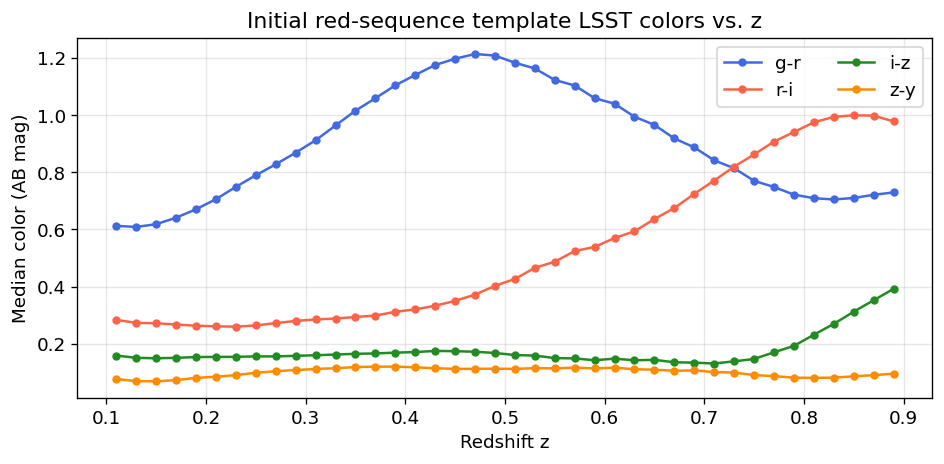

In [9]:
colors = ["g-r", "r-i", "i-z", "z-y"]
color_keys = ["gr",  "ri",  "iz",  "zy"]
palette = ["royalblue", "tomato", "forestgreen", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 4))
for key, label, col in zip(color_keys, colors, palette):
    ax.plot(rs["z"], rs[key], "o-", color=col, ms=4, lw=1.5, label=label)
ax.set_xlabel("Redshift z"); ax.set_ylabel("Median color (AB mag)")
ax.set_title("Initial red-sequence template LSST colors vs. z")
ax.legend(ncol=2)
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_redsequence.png"), dpi=150)
plt.show()

The 4000 angstrom "break" is from cool stars in old populations in galaxies have ionized metals in their atmospheres absorbing light in a way that suppresses shorter wavelengths and letting all the "redder" light through. A galaxy with a strong break is dim in the blue and bright in the red. As it gets redshifted, it changes what bands are useful. g-r is low redshift, r-i is medium to high redshift, i-z picks up tail end redshifts, z-y would be highest redshifts.  

g−r (blue) rises then declines with its peak showing where red galaxies look "reddest" if I'm interpreting that right

r−i (red) stays low and flat but clumbs after z=0.4. Can follow this trend to keep seeing (i-z green, z-y yellow to show the break-peak shifting). 

Each color peaks at the redshift where the 40k Angstrom break sits between that color's two bands. Knowing which color is peaking (which filter gap the break currently sits in) tells you the galaxy's redshift which is how redMaPPer assigns red-sequence redshifts and finds clusters as clumps of galaxies at the same redshift.

For redmapper, at any given redshift, the color whose break is currently in its gap provides the sharp constraint, while the others help resolve degeneracies and confirm the fit as it uses this to mape the "color-redshift" space.

## 6. Survey geometry mask

Purpose in redmapper: Defines which areas of sky are valid survey footprint, so the algorithm avoids spurious detections near edges and holes and computes correct survey area

Woohoo! This looks right

/global/homes/d/dericj/.conda/envs/desc_rm/lib/python3.11/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


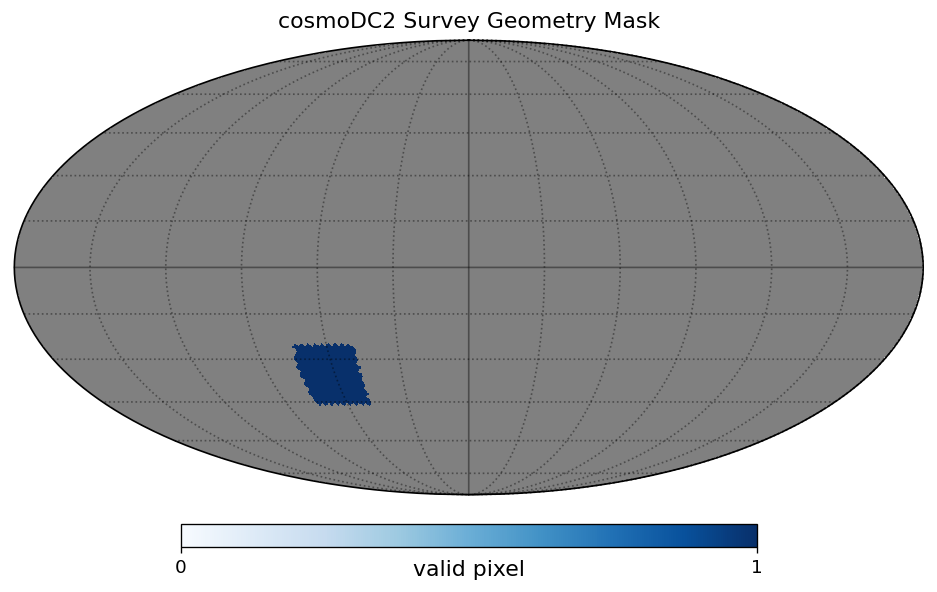

/global/homes/d/dericj/.conda/envs/desc_rm/lib/python3.11/site-packages/healpy/visufunc.py:835: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


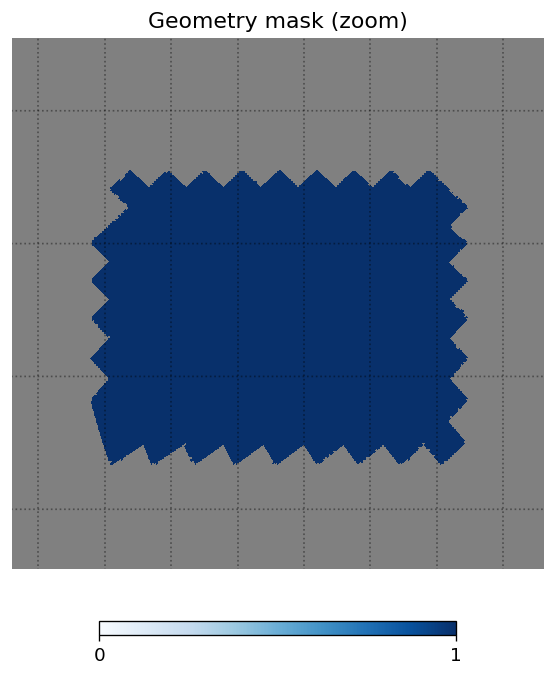

Valid pixels: 2,152,136


In [10]:
NSIDE_PLOT = 512
geom_full = geom_map.generate_healpix_map(nside=NSIDE_PLOT, nest=False)
geom_full[geom_full == 0] = hp.UNSEEN

fig = plt.figure(figsize=(10, 5))
hp.mollview(geom_full, fig=fig.number, title="cosmoDC2 Survey Geometry Mask", 
            cmap="Blues", unit="valid pixel", min=0, max=1, notext=True)
hp.graticule(dpar=15, dmer=30, alpha=0.4)
plt.savefig(os.path.join(OUT_DIR, "plot_geometry_mask.png"), dpi=150, bbox_inches="tight")
plt.show()

# zoom into the populated region with a cartview
ra_c = np.median(specz["ra"]); dec_c = np.median(specz["dec"])
fig = plt.figure(figsize=(7, 6))
hp.cartview(geom_full, fig=fig.number, title="Geometry mask (zoom)", 
            cmap="Blues", min=0, max=1, notext=True, lonra=[ra_c - 20, ra_c + 20], latra=[dec_c - 20, dec_c + 20])
hp.graticule(dpar=5, dmer=5, alpha=0.4)
plt.show()

print(f"Valid pixels: {len(geom_map.valid_pixels):,}")

## 7. Depth mask

Purpose in redmapper: Tells the algorithm how faint it can reliably detect galaxies at each location, enabling accurate richness measurements for higher-redshift clusters near the detection limit

All same color since I had no depth variation - so the skeleton for this works (faintest magnitude the survey can reliably detect at a given signal-to-noise threshold)

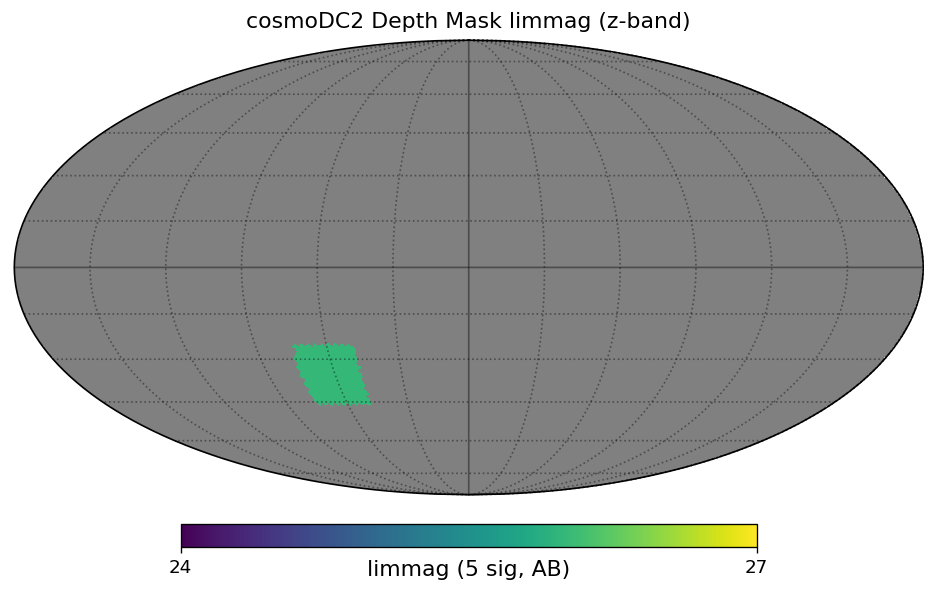

limmag range: 26.000 – 26.000  (uniform expected)
fracgood range: 1.000 - 1.000


In [11]:
valid_pix = depth_map.valid_pixels
depth_vals = depth_map[valid_pix]
limmag_vals = depth_vals["limmag"]
frac_vals = depth_vals["fracgood"]

# build a low-res healpy map of limmag for plotting
limmag_full = np.full(hp.nside2npix(NSIDE_PLOT), hp.UNSEEN)
theta, phi = hp.pix2ang(depth_map.nside_sparse, valid_pix, nest=True)
pix_lowres = hp.ang2pix(NSIDE_PLOT, theta, phi, nest=False)
limmag_full[pix_lowres] = limmag_vals

fig = plt.figure(figsize=(10, 5))
hp.mollview(limmag_full, fig=fig.number, title="cosmoDC2 Depth Mask limmag (z-band)", 
            cmap="viridis", unit="limmag (5 sig, AB)", min=24.0, max=27.0, notext=True)
hp.graticule(dpar=15, dmer=30, alpha=0.4)
plt.savefig(os.path.join(OUT_DIR, "plot_depth_mask.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"limmag range: {limmag_vals.min():.3f} – {limmag_vals.max():.3f}  "f"(uniform expected)")
print(f"fracgood range: {frac_vals.min():.3f} - {frac_vals.max():.3f}")

## 8. Cross-check: do all five trace the same footprint?

Overlay spec-z centrals, a photometric subsample, and the geometry mask boundary

In [12]:
'''
fig, ax = plt.subplots(figsize=(8, 7))

# geometry mask pixel centers (subsample)
gpix = geom_map.valid_pixels
gsub = np.random.choice(len(gpix), size=min(40_000, len(gpix)), replace=False)
gth, gph = hp.pix2ang(geom_map.nside_sparse, gpix[gsub], nest=True)
g_ra  = np.degrees(gph)
g_dec = 90.0 - np.degrees(gth)
ax.scatter(g_ra, g_dec, s=1, alpha=0.5, color="lightblue", label="geometry mask")

# photometric subsample
ax.scatter(photo["RA"][idx], photo["DEC"][idx], s=0.5, alpha=0.2, color="gray", label="photometric")

# spec-z on top
ax.scatter(specz["ra"], specz["dec"], s=10, color="red", edgecolor="k", lw=0.2, label="spec-z centrals")

ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("Footprint cross-check all ingredients")
ax.legend(markerscale=3, loc="best")
ax.invert_xaxis()
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_footprint_crosscheck.png"), dpi=150)
plt.show()
'''

'\nfig, ax = plt.subplots(figsize=(8, 7))\n\n# geometry mask pixel centers (subsample)\ngpix = geom_map.valid_pixels\ngsub = np.random.choice(len(gpix), size=min(40_000, len(gpix)), replace=False)\ngth, gph = hp.pix2ang(geom_map.nside_sparse, gpix[gsub], nest=True)\ng_ra  = np.degrees(gph)\ng_dec = 90.0 - np.degrees(gth)\nax.scatter(g_ra, g_dec, s=1, alpha=0.5, color="lightblue", label="geometry mask")\n\n# photometric subsample\nax.scatter(photo["RA"][idx], photo["DEC"][idx], s=0.5, alpha=0.2, color="gray", label="photometric")\n\n# spec-z on top\nax.scatter(specz["ra"], specz["dec"], s=10, color="red", edgecolor="k", lw=0.2, label="spec-z centrals")\n\nax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")\nax.set_title("Footprint cross-check all ingredients")\nax.legend(markerscale=3, loc="best")\nax.invert_xaxis()\nfig.tight_layout()\nplt.savefig(os.path.join(OUT_DIR, "plot_footprint_crosscheck.png"), dpi=150)\nplt.show()\n'

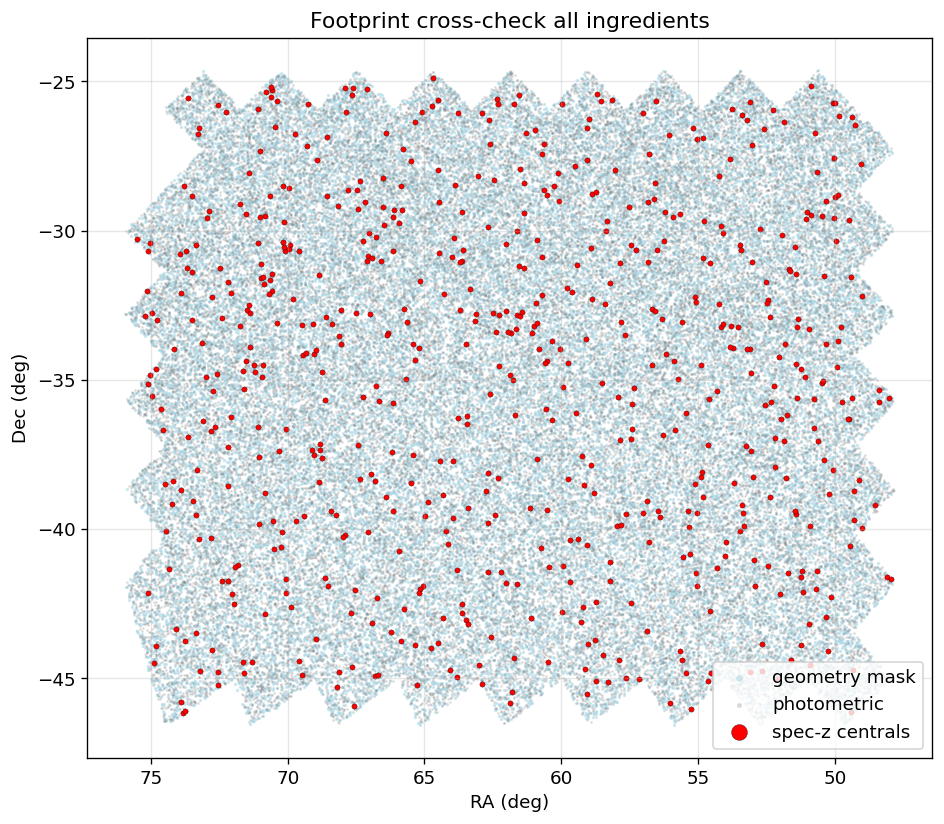

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
# geometry mask pixel centers (subsample)
gpix = geom_map.valid_pixels
gsub = np.random.choice(len(gpix), size=min(40_000, len(gpix)), replace=False)
gth, gph = hp.pix2ang(geom_map.nside_sparse, gpix[gsub], nest=True)
g_ra  = np.degrees(gph)
g_dec = 90.0 - np.degrees(gth)
ax.scatter(g_ra, g_dec, s=1, alpha=0.5, color="lightblue", label="geometry mask")
# photometric subsample
ax.scatter(photo.ra[idx], photo.dec[idx], s=0.5, alpha=0.2, color="gray", label="photometric")
# spec-z on top
ax.scatter(specz["ra"], specz["dec"], s=10, color="red", edgecolor="k", lw=0.2, label="spec-z centrals")
ax.set_xlabel("RA (deg)"); ax.set_ylabel("Dec (deg)")
ax.set_title("Footprint cross-check all ingredients")
ax.legend(markerscale=3, loc="best")
ax.invert_xaxis()
fig.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "plot_footprint_crosscheck.png"), dpi=150)
plt.show()